In [2]:
import jieba
import pandas as pd
import re

# 读取中文文本文件
with open(r'C:\Users\owner\Desktop\KG\上海市城市总体规划（2017-2035年）文本_final.txt', 'r', encoding='utf-8') as file:
    documents = file.readlines()

# 简单预处理：移除空行
documents = [doc.strip() for doc in documents if doc.strip()]

# 中文分词：使用 jieba 对每一行文本进行分词
documents_cut = [" ".join(jieba.cut(doc)) for doc in documents]  # 使用 " ".join() 保持分词之间的空格

# 去掉无意义的标点符号并替换为空格
documents_cut = [re.sub(r'[，。！？、【】（）〔〕《》“”‘’%…#&*]+', ' ', doc) for doc in documents_cut]

# 去掉多余的空格（将多个空格替换为一个空格）
documents = [re.sub(r'\s+', ' ', doc) for doc in documents_cut]

# 输出预处理后的文本（可以选择查看部分结果）
print(documents[:5])  # 输出前5行文本

# 如果你有特定的任务，可以将文本转为DataFrame等其他格式
df = pd.DataFrame(documents, columns=["Processed_Text"])
print(df.head())

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\owner\AppData\Local\Temp\jieba.cache
Loading model cost 0.574 seconds.
Prefix dict has been built successfully.


['上海市 城市 总体规划 2017 - 2035 年 文本', '上海市 城市 总体规划 2017 - 2035 年 文本', '二 〇 一 八年 一月 发布', '上海市人民政府 二 〇 一 八年 一月 发布', '国务院 关于 上海市 城市 总体规划 的 批复 国函 2017 147 号']
                          Processed_Text
0           上海市 城市 总体规划 2017 - 2035 年 文本
1           上海市 城市 总体规划 2017 - 2035 年 文本
2                         二 〇 一 八年 一月 发布
3                 上海市人民政府 二 〇 一 八年 一月 发布
4  国务院 关于 上海市 城市 总体规划 的 批复 国函 2017 147 号


In [3]:
import jieba
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

# 下载必要的资源
nltk.download('stopwords')

# 定义并更新停用词列表
stop_words = set(stopwords.words('chinese'))
# 手动添加中文停用词，避免像“可”这样的词被删除
stop_words.update(["的", "和", "与", "是", "为", "在", "上", "下", "对", "就", "等"])

# 自定义种子主题词汇列表（中文版本）
extended_seed_topics = {
    'adaptive capacity': ['适应能力', '适应性', '调整能力', '弹性', '恢复力', '应对能力', '适应性管理', '适应策略', '适应系统'],
    'climate proofing': ['气候变化', '气候适应', '气候保护', '气候预警', '气候适应基础设施'],
    'vulnerability assessment': ['脆弱性评估', '风险评估', '气候风险评估', '影响评估', '脆弱', '灾害'],
    'ecosystem-based adaptation': ['生态系统', '生态适应', '生态弹性', '生态变化', '生态调整', '环境适应'],
    'resilience': ['弹性', '恢复力', '韧性', '适应性', '抗压性', '韧性建设'],
    'transportation planning': ['交通规划', '公共交通', '公交', '地铁', '铁路', '交通系统', '可持续交通'],
    'zoning': ['分区', '区域规划', '土地使用', '城市土地规划', '土地管理'],
    'urban design': ['城市设计', '城市规划', '城市发展', '城市建筑', '城市景观设计'],
    'sustainable development': ['可持续', '可持续保护','可持续应对','绿色发展', '环境保护发展', '生态发展', '低碳发展'],
    'land use planning': ['土地使用规划', '土地管理', '空间规划', '土地政策', '土地开发']
}



# 在中文中词形还原通常不需要，假设你已经有一个关键词词汇表
flat_extended_seed_words = []
for sublist in extended_seed_topics.values():
    for word in sublist:
        flat_extended_seed_words.append(word)

# 中文分词后，去除停用词（英文停用词和自定义的中文停用词）
tokenized_docs = [
    [word for word in doc.split() if word not in stop_words]
    for doc in documents_cut
]

# 统计每个种子主题词汇在文档中的频率
word_freq = Counter()

# 处理每个文档，使用正则表达式匹配词组
for doc in tokenized_docs:
    doc_str = ' '.join(doc)  # 将分词后的文档重新合并为字符串
    for phrase, explanation in extended_seed_topics.items():
        for word in explanation:
            # 正则表达式匹配整个词组
            pattern = r'\b' + re.escape(word) + r'\b'
            matches = re.findall(pattern, doc_str)
            word_freq[phrase] += len(matches)

# 打印每个种子主题词汇的出现频率和对应的解释
for phrase, freq in word_freq.items():
    print(f"'{phrase}' ({', '.join(extended_seed_topics[phrase])}): {freq}")


'adaptive capacity' (适应能力, 适应性, 调整能力, 弹性, 恢复力, 应对能力, 适应性管理, 适应策略, 适应系统): 12
'climate proofing' (气候变化, 气候适应, 气候保护, 气候预警, 气候适应基础设施): 2
'vulnerability assessment' (脆弱性评估, 风险评估, 气候风险评估, 影响评估, 脆弱, 灾害): 5
'ecosystem-based adaptation' (生态系统, 生态适应, 生态弹性, 生态变化, 生态调整, 环境适应): 2
'resilience' (弹性, 恢复力, 韧性, 适应性, 抗压性, 韧性建设): 14
'transportation planning' (交通规划, 公共交通, 公交, 地铁, 铁路, 交通系统, 可持续交通): 76
'zoning' (分区, 区域规划, 土地使用, 城市土地规划, 土地管理): 12
'urban design' (城市设计, 城市规划, 城市发展, 城市建筑, 城市景观设计): 12
'sustainable development' (可持续, 可持续保护, 可持续应对, 绿色发展, 环境保护发展, 生态发展, 低碳发展): 0
'land use planning' (土地使用规划, 土地管理, 空间规划, 土地政策, 土地开发): 9


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
import csv
import unicodedata
import re
import jieba

# 初始化结果存储
results = []

# 停用词列表（可根据需要扩展）
stop_words = set(["的", "和", "与", "是", "为", "在", "上", "下", "对", "就", "等"])

def clean_text(text):
    """清理文本中不可见字符、特殊符号和非中文字符"""
    text = ''.join(c for c in text if unicodedata.category(c)[0] != 'C')  # 移除控制字符
    text = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9，。！？、；：]', ' ', text)  # 保留中文、英文、数字及常见标点
    text = re.sub(r'\s+', ' ', text).strip()  # 去除多余空格
    return text

def split_sentences(text):
    """按中文标点分割句子"""
    sentences = re.split(r'[。！？]', text)
    return [s.strip() for s in sentences if s.strip()]

# 处理每个文档，按句分割并查找匹配
for doc in documents:  # 假设 documents 是一个文档列表
    doc = clean_text(doc)  # 清理文档中的特殊字符
    sentences = split_sentences(doc)  # 按中文句号分句
    for sentence in sentences:
        # 使用 jieba 分词并去停用词
        tokenized_sentence = [word for word in jieba.cut(sentence) if word not in stop_words]
        tokenized_sentence_str = ' '.join(tokenized_sentence)

        # 检查匹配
        for phrase, explanation in extended_seed_topics.items():
            for word in explanation:
                pattern = r'\b' + re.escape(word) + r'\b'
                if re.search(pattern, tokenized_sentence_str):
                    results.append({
                        'Topic': phrase,
                        'Matched Word': word,
                        'Sentence': sentence
                    })

# 将结果保存到 CSV 文件
csv_file = r"C:\Users\owner\Desktop\KG\matched_sentences_SH.csv"
with open(csv_file, mode='w', newline='', encoding='utf-8-sig') as file:  # 使用 utf-8-sig 编码
    writer = csv.DictWriter(file, fieldnames=['Topic', 'Matched Word', 'Sentence'])
    writer.writeheader()
    writer.writerows(results)

print(f"Results have been saved to {csv_file}")


Results have been saved to C:\Users\owner\Desktop\KG\matched_sentences_SH.csv


关键词共现矩阵：
                            adaptive capacity  climate proofing  \
adaptive capacity                         0.0               0.0   
climate proofing                          0.0               0.0   
vulnerability assessment                  0.0               0.0   
ecosystem-based adaptation                0.0               0.0   
resilience                               12.0               0.0   
transportation planning                   0.0               0.0   
zoning                                    1.0               0.0   
urban design                              0.0               0.0   
sustainable development                   0.0               0.0   
land use planning                         0.0               0.0   

                            vulnerability assessment  \
adaptive capacity                                0.0   
climate proofing                                 0.0   
vulnerability assessment                         0.0   
ecosystem-based adaptation   

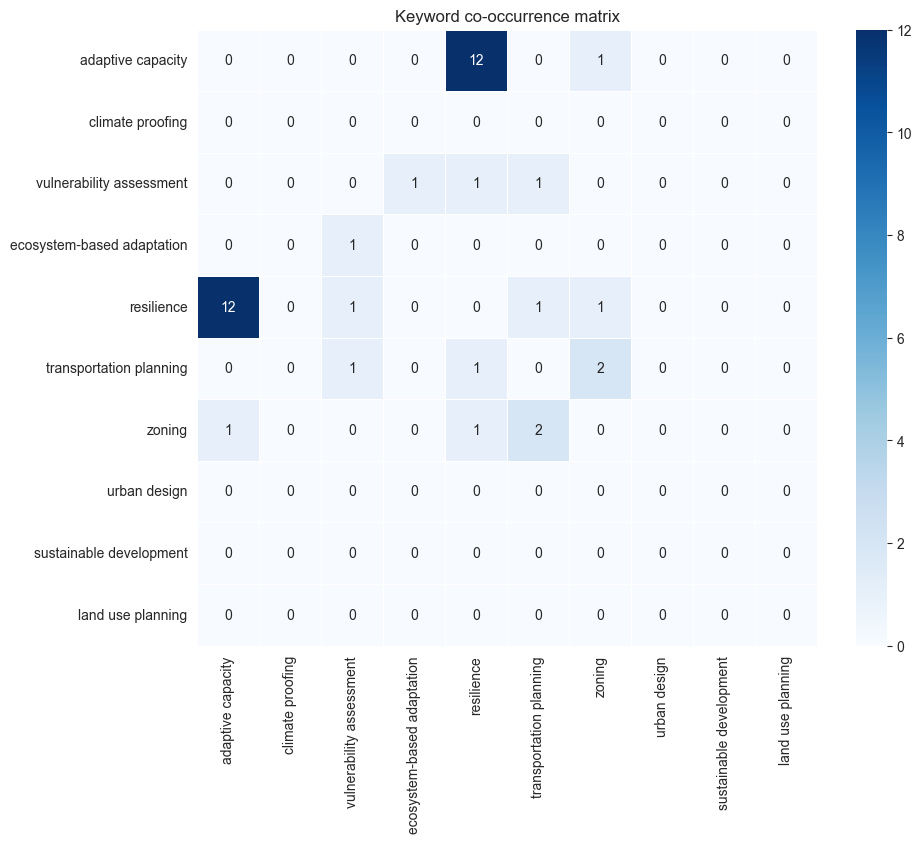

In [5]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import nltk
import jieba


# 构建共现矩阵（基于词频）
def build_cooccurrence_matrix(freq, documents, keywords):
    # 创建一个空的共现矩阵
    co_matrix = pd.DataFrame(np.zeros((len(keywords), len(keywords))),
                             index=keywords.keys(), columns=keywords.keys())

    # 遍历每个文档
    for doc in tokenized_docs:
        found_keywords = set()  # 存储当前文档中出现的关键词
        for main_keyword, syns in keywords.items():
            # 查找当前文档中是否包含这些关键词
            for word in syns:
                if word in doc:
                    found_keywords.add(main_keyword)

        # 更新共现矩阵
        for kw1 in found_keywords:
            for kw2 in found_keywords:
                if kw1 != kw2:
                    co_matrix.at[kw1, kw2] += 1

    return co_matrix

# 生成共现矩阵
cooccurrence_matrix = build_cooccurrence_matrix(freq, documents, extended_seed_topics)

# 打印共现矩阵
print("关键词共现矩阵：")
print(cooccurrence_matrix)

# 可视化共现矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence_matrix, annot=True, cmap='Blues', fmt='g', linewidths=0.5)
plt.title("Keyword co-occurrence matrix")
plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                            adaptive capacity  climate proofing  \
adaptive capacity                    0.000000          0.000000   
climate proofing                     0.000000          0.000000   
vulnerability assessment             0.000000          0.000000   
ecosystem-based adaptation           0.000000          0.000000   
resilience                           0.012072          0.000000   
transportation planning              0.000000          0.000000   
zoning                               0.001006          0.000000   
urban design                         0.000000          0.000000   
sustainable development              0.000000          0.000000   
land use planning                    0.000000          0.000000   

                            vulnerability assessment  \
adaptive capacity                           0.000000   
climate proofing                            0.000000   
vulnerability assessment                    0.000000   
ecosystem-based adaptation            

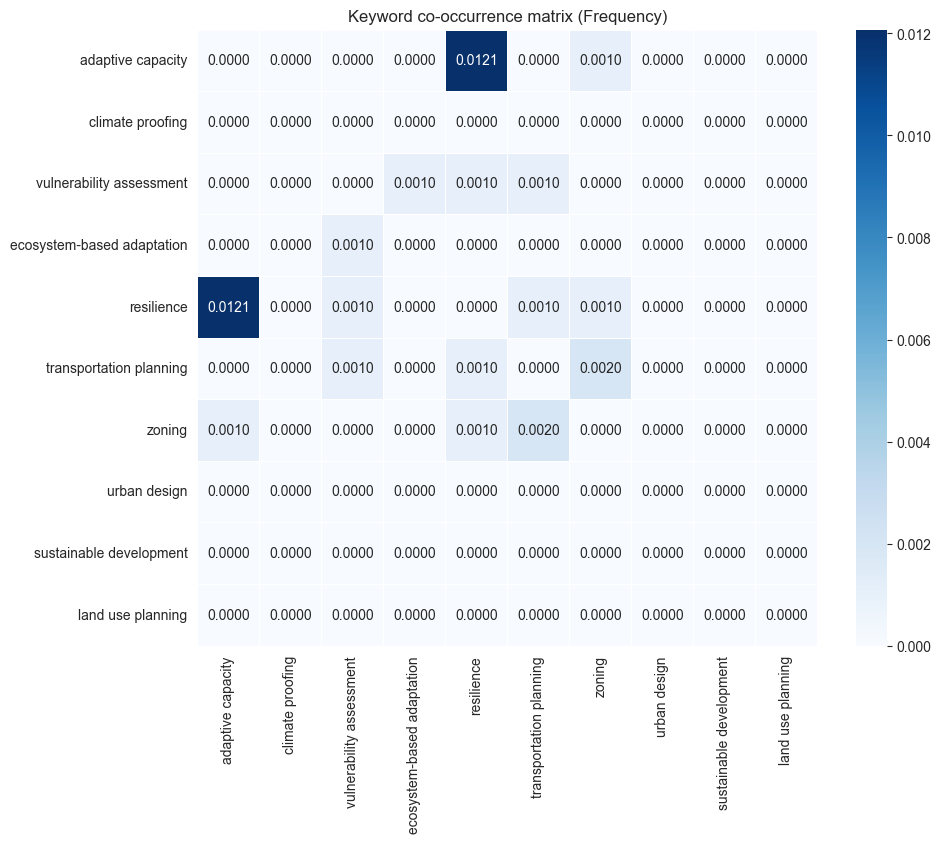

In [6]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

# 关键词及其近义词集合
keywords = extended_seed_topics

# 下载nltk所需的资源
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 构建共现矩阵（频率版）
def build_cooccurrence_matrix(freq, documents, keywords):
    co_matrix = pd.DataFrame(np.zeros((len(keywords), len(keywords))),
                             index=keywords.keys(), columns=keywords.keys())
    total_documents = len(documents)  # 总文档数

    for document in documents:
        found_keywords = set()  # 存储当前文档中出现的关键词
        for main_keyword, syns in keywords.items():
            pattern = r'\b(?:' + '|'.join(syns) + r')\b'
            if re.search(pattern, document.lower()):
                found_keywords.add(main_keyword)

        # 更新共现矩阵
        for kw1 in found_keywords:
            for kw2 in found_keywords:
                if kw1 != kw2:
                    co_matrix.at[kw1, kw2] += 1

    # 将每个元素的次数除以文档总数，计算频率
    co_matrix = co_matrix / total_documents

    return co_matrix


# 生成共现矩阵
cooccurrence_matrix = build_cooccurrence_matrix(freq, documents, extended_seed_topics)

pd.options.display.float_format = '{:.6f}'.format
print(cooccurrence_matrix)

# 可视化共现矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence_matrix, annot=True, cmap='Blues', fmt='.4f', linewidths=0.5)  # 显示4位小数
plt.title("Keyword co-occurrence matrix (Frequency)")
plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
C:\Users\owner\AppData\Local\Temp\ipykernel_27152\2202626056.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keywords_list, y=frequencies, palette='Blues_d')

每个关键词的频率：
{'urban design': 0.008048289738430584, 'adaptive capacity': 0.012072434607645875, 'resilience': 0.014084507042253521, 'vulnerability assessment': 0.004024144869215292, 'transportation planning': 0.04024144869215292, 'zoning': 0.011066398390342052, 'climate proofing': 0.002012072434607646, 'land use planning': 0.006036217303822937, 'ecosystem-based adaptation': 0.002012072434607646}


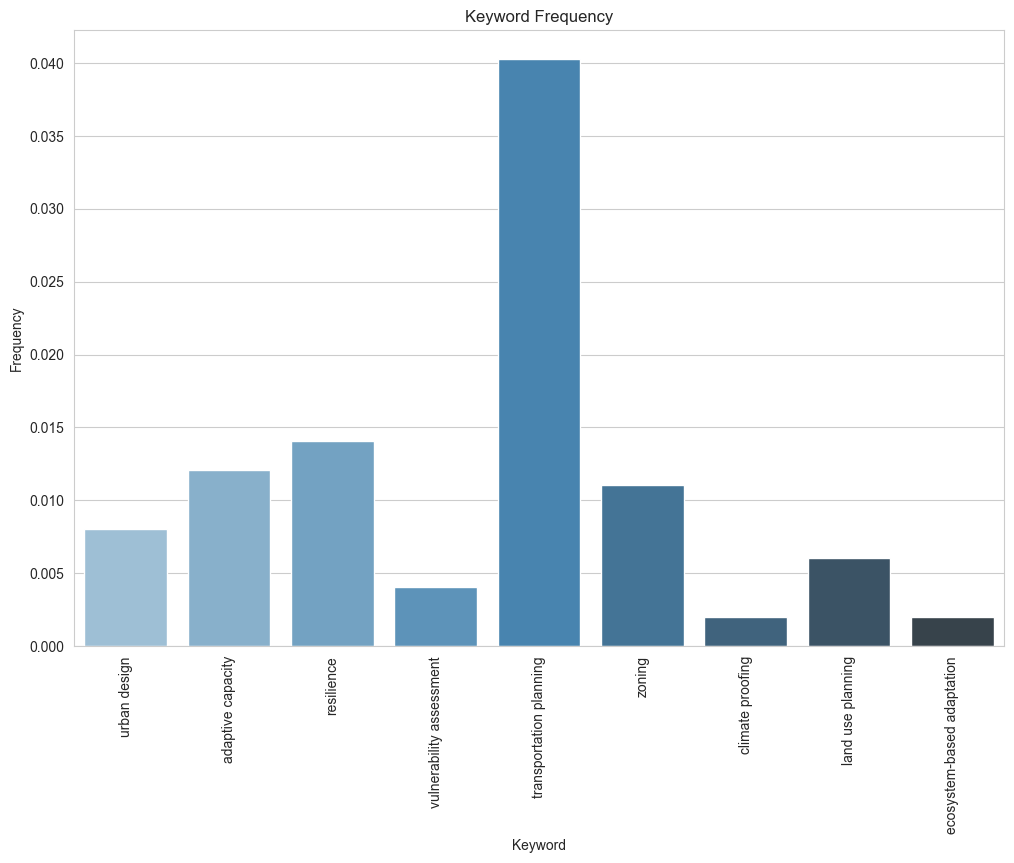

In [7]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

# 关键词及其近义词集合
keywords = extended_seed_topics

# 下载nltk所需的资源
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 构建关键词的频率（频率版）
def build_keyword_frequency(documents, keywords):
    keyword_freq = defaultdict(int)  # 用于存储每个关键词的出现次数
    total_documents = len(documents)  # 总文档数

    for document in documents:
        found_keywords = set()  # 存储当前文档中出现的关键词
        for main_keyword, syns in keywords.items():
            pattern = r'\b(?:' + '|'.join(syns) + r')\b'
            if re.search(pattern, document.lower()):
                found_keywords.add(main_keyword)

        # 更新关键词频率
        for kw in found_keywords:
            keyword_freq[kw] += 1

    # 将每个关键词的出现次数除以文档总数，得到频率
    keyword_frequency = {kw: freq / total_documents for kw, freq in keyword_freq.items()}

    return keyword_frequency

# 获取每个关键词的频率
keyword_frequency = build_keyword_frequency(documents, extended_seed_topics)

print("每个关键词的频率：")
print(keyword_frequency)

# 可视化关键词频率
keywords_list = list(keyword_frequency.keys())
frequencies = list(keyword_frequency.values())

plt.figure(figsize=(12, 8))
sns.barplot(x=keywords_list, y=frequencies, palette='Blues_d')
plt.xticks(rotation=90)
plt.title("Keyword Frequency")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.show()


In [8]:
word_freq.items()

dict_items([('adaptive capacity', 12), ('climate proofing', 2), ('vulnerability assessment', 5), ('ecosystem-based adaptation', 2), ('resilience', 14), ('transportation planning', 76), ('zoning', 12), ('urban design', 12), ('sustainable development', 0), ('land use planning', 9)])

In [9]:
keyword_frequency

{'urban design': 0.008048289738430584,
 'adaptive capacity': 0.012072434607645875,
 'resilience': 0.014084507042253521,
 'vulnerability assessment': 0.004024144869215292,
 'transportation planning': 0.04024144869215292,
 'zoning': 0.011066398390342052,
 'climate proofing': 0.002012072434607646,
 'land use planning': 0.006036217303822937,
 'ecosystem-based adaptation': 0.002012072434607646}

In [10]:
# Ensure values are rounded and formatted to 4 decimal places
V1_rounded = {key: format(value, '.3f') for key, value in keyword_frequency.items()}

print(V1_rounded)

{'urban design': '0.008', 'adaptive capacity': '0.012', 'resilience': '0.014', 'vulnerability assessment': '0.004', 'transportation planning': '0.040', 'zoning': '0.011', 'climate proofing': '0.002', 'land use planning': '0.006', 'ecosystem-based adaptation': '0.002'}


In [11]:
# 定义自定义顺序列表
custom_order = ['resilience', 'adaptive capacity', 'vulnerability assessment', 'climate proofing',
                'ecosystem-based adaptation', 'zoning', 'land use planning', 'urban design',
                'transportation planning', 'sustainable development']

# 按照自定义顺序重新排序 keyword_frequency
keyword_frequency = {key: keyword_frequency[key] for key in custom_order if key in keyword_frequency}

# 打印排序后的结果
print(keyword_frequency)


{'resilience': 0.014084507042253521, 'adaptive capacity': 0.012072434607645875, 'vulnerability assessment': 0.004024144869215292, 'climate proofing': 0.002012072434607646, 'ecosystem-based adaptation': 0.002012072434607646, 'zoning': 0.011066398390342052, 'land use planning': 0.006036217303822937, 'urban design': 0.008048289738430584, 'transportation planning': 0.04024144869215292}


In [12]:
cooccurrence_matrix

,adaptive capacity,climate proofing,vulnerability assessment,ecosystem-based adaptation,resilience,transportation planning,zoning,urban design,sustainable development,land use planning
adaptive capacity,0.000000,0.000000,0.000000,0.000000,0.012072,0.000000,0.001006,0.000000,0.000000,0.000000
climate proofing,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
vulnerability assessment,0.000000,0.000000,0.000000,0.001006,0.001006,0.001006,0.000000,0.000000,0.000000,0.000000
ecosystem-based adaptation,0.000000,0.000000,0.001006,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
resilience,0.012072,0.000000,0.001006,0.000000,0.000000,0.001006,0.001006,0.000000,0.000000,0.000000
transportation planning,0.000000,0.000000,0.001006,0.000000,0.001006,0.000000,0.002012,0.000000,0.000000,0.000000
zoning,0.001006,0.000000,0.000000,0.000000,0.001006,0.002012,0.000000,0.000000,0.000000,0.000000
urban design,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
sustainable development,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
land use planning,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


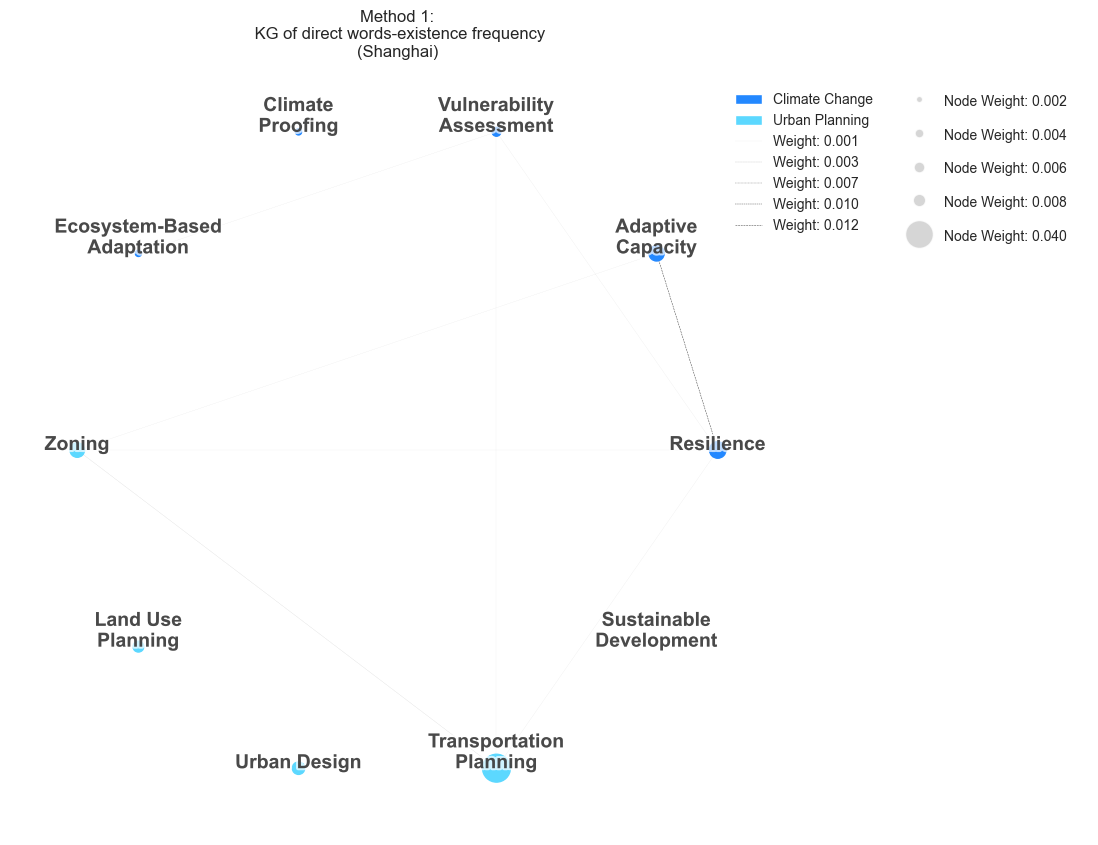

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
# 假设已经有了 keyword_counts 和 cooccurrence_matrix
import textwrap

# 创建一个空的无向图
G = nx.Graph()

# 添加节点，节点的权重是关键词的出现频率
for keyword, count in keyword_frequency.items():
    G.add_node(keyword, size=count)

# 添加边，边的权重是共现次数
for keyword1, cooccurrences in cooccurrence_matrix.items():
    for keyword2, count in cooccurrences.items():
        if keyword1 != keyword2:  # 避免自环
            G.add_edge(keyword1, keyword2, weight=count)
l=50
k=200
j=30

# 假设 G 中的节点名称与 word_freq 中的键（主题词）相匹配
#node_sizes = [keyword_frequency[node] * 50 for node in G.nodes()]  # 使用 keyword_frequency 中的频率来设置节点大小
node_sizes = [keyword_frequency.get(node, 0) * l if keyword_frequency.get(node, 0) > 0 else 0 for node in G.nodes()]
# 设置边的宽度，按共现次数来调整
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

# 定义自定义顺序列表
custom_order = ['resilience', 'adaptive capacity', 'vulnerability assessment', 'climate proofing', 'ecosystem-based adaptation', 'zoning', 'land use planning', 'urban design', 'transportation planning', 'sustainable development']

# 使用自定义顺序对节点列表进行排序
node_list = list(G.nodes())

# 将节点按照 custom_order 中的顺序排列
node_list.sort(key=lambda x: custom_order.index(x))

# 圆形布局：将节点均匀地分布在圆形上
radius = 1.5  # 控制圆的半径
pos = {}
num_nodes = len(node_list)
for i, node in enumerate(node_list):
    angle = 2 * np.pi * i / num_nodes  # 均匀分布节点位置
    pos[node] = (radius * np.cos(angle), radius * np.sin(angle))

# 绘制图形
plt.figure(figsize=(10, 10))

# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    #nodelist=list(extended_seed_topics.keys())[:5],  # 前五个节点
    nodelist=custom_order[:5],
    node_color="#2388FF",
    node_size=[size * k for size in node_sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)

# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    #nodelist=list(extended_seed_topics.keys())[5:],
    nodelist=custom_order[5:],# 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in node_sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)


# 在绘制标签时，添加白色描边
for node, (x, y) in pos.items():
    weight = f"{keyword_frequency.get(node, 0):.3f}" if keyword_frequency.get(node, 0) > 0 else "0"   # 获取当前节点的权重  # 获取当前节点的权重  # 获取节点的权重
    modified_node = f"{node}"#\n{weight:.2f}
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='#111111', alpha=0.7
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])

edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]



nx.draw_networkx_edges(
    G,
    pos,
    width=[edge_weight * j for edge_weight in edge_weights],
    alpha=0.8,
    style='--',
    edge_color='#111111')


weights2 = [w for w in weights1 if w > 0]  # 过滤掉所有非正数权重
min_weight, max_weight = min(weights2), max(weights1)

# 不再归一化，直接使用原始权重
example_weights = [min_weight, (min_weight + max_weight) / 4, (min_weight + max_weight) / 2, (min_weight + max_weight) / 4 * 3, max_weight]
example_widths = [min_weight * j, (min_weight + max_weight) / 4 * j, (min_weight + max_weight) / 2 * j, (min_weight + max_weight) / 4 * 3 * j, max_weight * j]


# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning')   # 黄色固定节点
]
# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size*k) for size in node_sizes]  # 根据绘图的node_size计算半径
legend_node_weights = [node_weight/50 for node_weight in node_sizes]

# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 6

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

# 添加边权重示例
for w, width in zip(example_weights, example_widths):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            linestyle='--',
            label=f"Weight: {w:.3f}"
        )
    )
# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Node Weight: {weight:.3f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:7],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    frameon=False,
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例
# 绘制边权重图例
plt.legend(
    handles=legend_elements[7:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=1.2,  # 增加标签之间的垂直间距
    handleheight=1.5,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)
# 显示图形
plt.title('Method 1:\n KG of direct words-existence frequency\n(Shanghai)')
plt.axis('off')
plt.show()


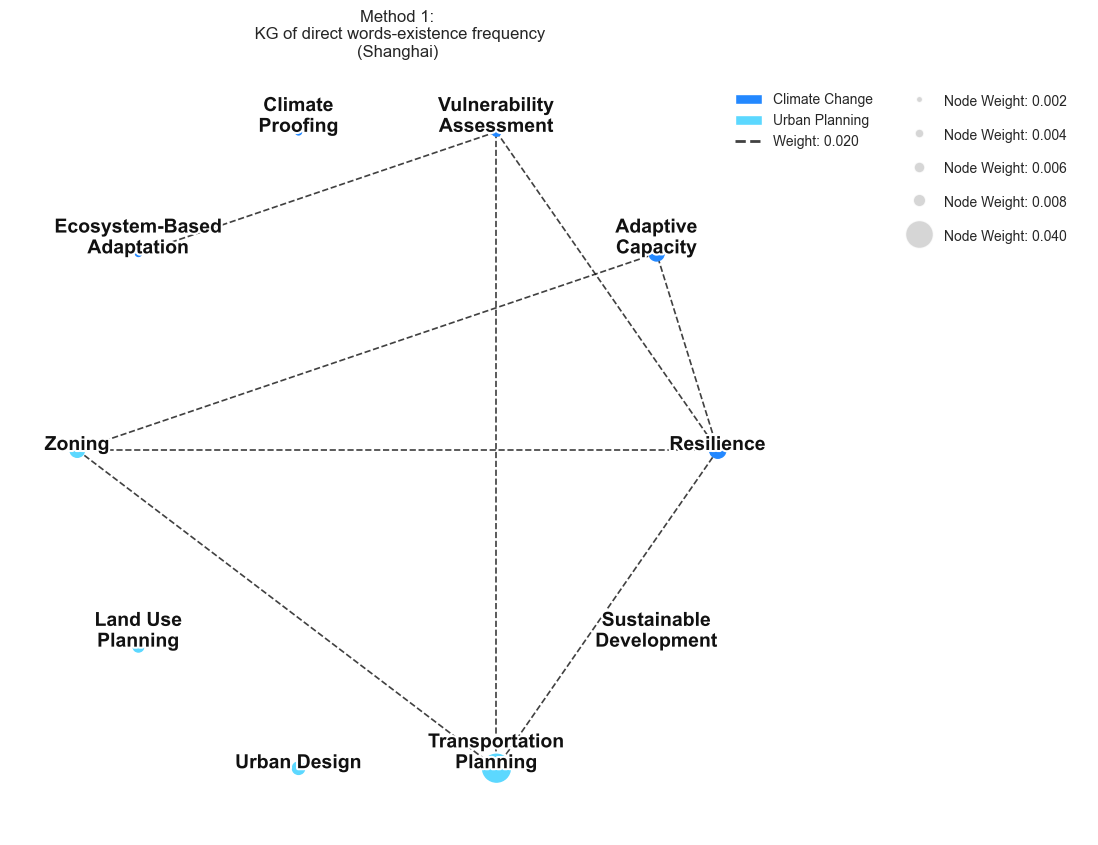

In [26]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
# 假设已经有了 keyword_counts 和 cooccurrence_matrix
import textwrap

# 创建一个空的无向图
G = nx.Graph()

# 添加节点，节点的权重是关键词的出现频率
for keyword, count in keyword_frequency.items():
    G.add_node(keyword, size=count)

# 添加边，边的权重是共现次数
for keyword1, cooccurrences in cooccurrence_matrix.items():
    for keyword2, count in cooccurrences.items():
        if keyword1 != keyword2:  # 避免自环
            G.add_edge(keyword1, keyword2, weight=count)
l=50
k=200
j=100

# 假设 G 中的节点名称与 word_freq 中的键（主题词）相匹配
#node_sizes = [keyword_frequency[node] * 50 for node in G.nodes()]  # 使用 keyword_frequency 中的频率来设置节点大小
node_sizes = [keyword_frequency.get(node, 0) * l if keyword_frequency.get(node, 0) > 0 else 0 for node in G.nodes()]
# 设置边的宽度，按共现次数来调整
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

# 定义自定义顺序列表
custom_order = ['resilience', 'adaptive capacity', 'vulnerability assessment', 'climate proofing', 'ecosystem-based adaptation', 'zoning', 'land use planning', 'urban design', 'transportation planning', 'sustainable development']

# 使用自定义顺序对节点列表进行排序
node_list = list(G.nodes())

# 将节点按照 custom_order 中的顺序排列
node_list.sort(key=lambda x: custom_order.index(x))

# 圆形布局：将节点均匀地分布在圆形上
radius = 1.5  # 控制圆的半径
pos = {}
num_nodes = len(node_list)
for i, node in enumerate(node_list):
    angle = 2 * np.pi * i / num_nodes  # 均匀分布节点位置
    pos[node] = (radius * np.cos(angle), radius * np.sin(angle))

# 绘制图形
plt.figure(figsize=(10, 10))

# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    #nodelist=list(extended_seed_topics.keys())[:5],  # 前五个节点
    nodelist=custom_order[:5],
    node_color="#2388FF",
    node_size=[size * k for size in node_sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)

# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    #nodelist=list(extended_seed_topics.keys())[5:],
    nodelist=custom_order[5:],# 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in node_sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)


# 在绘制标签时，添加白色描边
for node, (x, y) in pos.items():
    weight = f"{keyword_frequency.get(node, 0):.3f}" if keyword_frequency.get(node, 0) > 0 else "0"   # 获取当前节点的权重  # 获取当前节点的权重  # 获取节点的权重
    modified_node = f"{node}"#\n{weight:.2f}
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='#111111'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])

edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]

# 设置两个阈值
threshold = 0.02
# 获取当前边权重中的最大值
max_edge_weight = max(edge_weights)

# 应用阈值逻辑处理边权重
processed_edge_weights = []
for weight in edge_weights:
    if weight < threshold and  weight!=0:
        processed_edge_weights.append(max_edge_weight)  # 替换为最大值
    else:
        processed_edge_weights.append(weight)  # 保留原始值

# 使用处理后的权重绘制边
nx.draw_networkx_edges(
    G,
    pos,
    width=[edge_weight * j for edge_weight in processed_edge_weights],
    alpha=0.8,
    style='--',
    edge_color='#111111'
)


weights2 = [w for w in weights1 if w > 0]  # 过滤掉所有非正数权重
min_weight, max_weight = min(weights2), max(weights1)

# 更新示例边权重和线宽，根据阈值进行动态调整
example_weights = [threshold]
example_widths = [threshold * j]

# 添加图例中的边权重部分
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning')   # 黄色固定节点
]


# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size*k) for size in node_sizes]  # 根据绘图的node_size计算半径
legend_node_weights = [node_weight/50 for node_weight in node_sizes]

# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 6

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

# 添加边权重示例
for w, width in zip(example_weights, example_widths):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            linestyle='--',
            label=f"Weight: {w:.3f}"
        )
    )
# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Node Weight: {weight:.3f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:3],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    frameon=False,
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例
# 更新图例中的边权重图例
plt.legend(
    handles=legend_elements[3:],  # 仅添加边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=1.2,  # 增加标签之间的垂直间距
    handleheight=1.5,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)
# 显示图形
plt.title('Method 1:\n KG of direct words-existence frequency\n(Shanghai)')
plt.axis('off')
plt.show()
